In [2]:
# %% [markdown]
# # LLM-Guided Counterfactual Intervention for Comorbid Chronic Disease Risk
# **Framework**: XGBoost (Stage 1) → GPT-4o-mini Guardrail Agent (Stage 2) → DiCE (Stage 3)
# **Data**: KNHANES 2020–2024

# %% [markdown]
# ## 0. Library Import & Settings

# %%
import json
import joblib
import numpy as np
import optuna
import pandas as pd
import pyreadstat
import xgboost as xgb
import openai
import dice_ml

from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
pd.set_option('display.max_colwidth', None)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# OpenAI API key
OPENAI_API_KEY = "YOUR_API_KEY_HERE"   # ← Enter your API key here
client = openai.OpenAI(api_key=OPENAI_API_KEY)

# %% [markdown]
# ## 1. KNHANES 2020–2024 Data Merge

# %%
df20, meta20 = pyreadstat.read_sas7bdat('hn20_all.sas7bdat')
df21, meta21 = pyreadstat.read_sas7bdat('hn21_all.sas7bdat')
df22, meta22 = pyreadstat.read_sas7bdat('hn22_all.sas7bdat')
df23, meta23 = pyreadstat.read_sas7bdat('hn23_all.sas7bdat')
df24, meta24 = pyreadstat.read_sas7bdat('hn24_all.sas7bdat')

# %% [markdown]
# ### 1-1. Variable Selection

# %%
KEY_COLS    = ['ID', 'year', 'sex']
CAT_COLS    = [
    'HE_obe', 'BO1_1', 'BO1_2', 'BO1_3', 'BD1_11', 'BD2_1', 'BS3_1',
    'BE3_71', 'BE3_75', 'BE3_81', 'BE3_91', 'pa_aerobic', 'L_BR_FQ',
    'BP1', 'mh_stress', 'incm', 'ho_incm', 'edu', 'BH1',
]
NUM_COLS    = [
    'HE_BMI', 'HE_wc', 'HE_wt',
    'N_EN', 'N_CHO', 'N_SUGAR', 'N_NA', 'N_FAT',
    'N_SFA', 'N_TDF', 'N_K', 'N_PROT',
]
TARGET_COLS = ['HE_DM_HbA1c', 'HE_HP']
ALL_VARS    = KEY_COLS + CAT_COLS + NUM_COLS + TARGET_COLS

# %% [markdown]
# ### 1-2. Filter & Merge

# %%
df_total = pd.concat(
    [d[ALL_VARS].copy() for d in [df20, df21, df22, df23, df24]], axis=0
).reset_index(drop=True)

# %% [markdown]
# ### 1-3. Target Variable Encoding

# %%
# HE_DM_HbA1c: 1=Normal→0, 3=Diabetes→1
df_total['HE_DM_HbA1c'] = df_total['HE_DM_HbA1c'].map({1: 0, 3: 1}).fillna(-999)
# HE_HP: 1=Normal→0, 4=Hypertension→1
df_total['HE_HP']        = df_total['HE_HP'].map({1: 0, 4: 1}).fillna(-999)

for col in ['HE_DM_HbA1c', 'HE_HP']:
    print(f"\n{col} value counts:\n", df_total[col].value_counts())

# %% [markdown]
# ### 1-4. Integrated 4-Class Risk Label

# %%
# Class 0: Normal | Class 1: HTN-only | Class 2: DM-only | Class 3: Comorbid
conditions = [
    (df_total['HE_DM_HbA1c'] == 0) & (df_total['HE_HP'] == 0),
    (df_total['HE_DM_HbA1c'] == 0) & (df_total['HE_HP'] == 1),
    (df_total['HE_DM_HbA1c'] == 1) & (df_total['HE_HP'] == 0),
    (df_total['HE_DM_HbA1c'] == 1) & (df_total['HE_HP'] == 1),
]
df_total['integrated_target'] = np.select(conditions, [0, 1, 2, 3], default=np.nan)
df_total = df_total.dropna().reset_index(drop=True)
df_total['integrated_target'] = df_total['integrated_target'].astype(int)

print("Risk class distribution:")
print(df_total['integrated_target'].value_counts().sort_index())

# %% [markdown]
# ### 1-5. Rename Columns: SAS codes → English labels

# %%
# English column mapping (SAS variable code → English label)
ENGLISH_LABEL_DICT = {
    'ID':           'ID',
    'year':         'SurveyYear',
    'sex':          'Sex',
    'HE_DM_HbA1c':  'Diabetes',
    'HE_HP':        'Hypertension',
    'integrated_target': 'RiskClass',
    # Categorical
    'HE_obe':   'ObesityStatus',
    'BO1_1':    'WeightChangeStatus',
    'BO1_2':    'WeightLossAmount',
    'BO1_3':    'WeightGainAmount',
    'BD1_11':   'DrinkingFrequency',
    'BD2_1':    'DrinkingAmount',
    'BS3_1':    'SmokingStatus',
    'BE3_71':   'VigorousActivity_Work',
    'BE3_75':   'VigorousActivity_Leisure',
    'BE3_81':   'ModerateActivity_Work',
    'BE3_91':   'WalkingActivity',
    'pa_aerobic': 'AerobicActivityRate',
    'L_BR_FQ':  'BreakfastFrequency',
    'BP1':      'StressLevel',
    'mh_stress':'StressAwarenessRate',
    'incm':     'PersonalIncomeQuartile',
    'ho_incm':  'HouseholdIncomeQuartile',
    'edu':      'EducationLevel',
    'BH1':      'HealthScreeningStatus',
    # Numerical
    'HE_BMI':   'BMI',
    'HE_wc':    'WaistCirc',
    'HE_wt':    'Weight',
    'N_EN':     'Energy_kcal',
    'N_CHO':    'Carb_g',
    'N_SUGAR':  'Sugar_g',
    'N_NA':     'Sodium_mg',
    'N_FAT':    'Fat_g',
    'N_SFA':    'SaturatedFat_g',
    'N_TDF':    'Fiber_g',
    'N_K':      'Potassium_mg',
    'N_PROT':   'Protein_g',
}

df_total.rename(columns=ENGLISH_LABEL_DICT, inplace=True)
df_total.to_csv('./knhanes_comorbid_2020_2024.csv', index=False, encoding='utf-8-sig')
print(">>> Preprocessing complete. CSV saved.")
df_total.head()

# %% [markdown]
# ## 2. Feature Definition & Numeric Dataset

# %%
NUM_FEATURES = [
    'BMI', 'WaistCirc', 'Weight',
    'Energy_kcal', 'Carb_g', 'Sugar_g', 'Sodium_mg',
    'Fat_g', 'SaturatedFat_g', 'Fiber_g', 'Potassium_mg', 'Protein_g',
]

CAT_FEATURES = [
    'ObesityStatus', 'WeightChangeStatus', 'WeightLossAmount', 'WeightGainAmount',
    'DrinkingFrequency', 'DrinkingAmount', 'SmokingStatus',
    'VigorousActivity_Work', 'VigorousActivity_Leisure',
    'ModerateActivity_Work', 'WalkingActivity', 'AerobicActivityRate',
    'BreakfastFrequency', 'StressLevel', 'StressAwarenessRate',
    'PersonalIncomeQuartile', 'HouseholdIncomeQuartile',
    'EducationLevel', 'HealthScreeningStatus',
]

X_FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET_COL  = 'RiskClass'

# Variables excluded from DiCE intervention search:
# These are either non-modifiable (stress perception, income, education)
# or administrative (health screening status).
# DiCE will hold them fixed at the patient's current value.
FIXED_FEATURES = [
    'StressLevel', 'StressAwarenessRate',
    'PersonalIncomeQuartile', 'HouseholdIncomeQuartile',
    'EducationLevel', 'HealthScreeningStatus',
]
VARY_FEATURES = [f for f in X_FEATURES if f not in FIXED_FEATURES]

# Build all-numeric dataset for XGBoost & DiCE
required_cols = X_FEATURES + [TARGET_COL, 'Sex']
df_final = df_total[required_cols].copy()
for col in df_final.columns:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce').fillna(0)
df_final = df_final.astype(float)

print(f"df_final shape : {df_final.shape}")
print(f"Any string column: {(df_final.dtypes == 'object').any()}")


HE_DM_HbA1c value counts:
 HE_DM_HbA1c
-999.0    17438
 0.0      12810
 1.0       4392
Name: count, dtype: int64

HE_HP value counts:
 HE_HP
-999.0    16734
 0.0      11964
 1.0       5942
Name: count, dtype: int64
Risk class distribution:
integrated_target
0    6381
1    1370
2     649
3    1338
Name: count, dtype: int64
>>> Preprocessing complete. CSV saved.
df_final shape : (9738, 33)
Any string column: False


In [ ]:
# %% [markdown]
# ## 3. Stage 1 — XGBoost Gender-Stratified Training (Optuna)

# %%
def train_model(gender_code: float, gender_name: str):
    print(f"\n{'='*20} {gender_name} Model Training {'='*20}")

    df_g = df_final[df_final['Sex'] == gender_code].copy()
    X = df_g[X_FEATURES]
    y = df_g[TARGET_COL].astype(int)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    sw = compute_sample_weight('balanced', y=y_train)

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'max_depth':        trial.suggest_int('max_depth', 3, 7),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample':        trial.suggest_float('subsample', 0.7, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
            'objective':        'multi:softprob',
            'num_class':        4,
            'tree_method':      'hist',
            'random_state':     42,
        }
        mdl = xgb.XGBClassifier(**params)
        mdl.fit(X_train, y_train, sample_weight=sw)
        return f1_score(y_val, mdl.predict(X_val), average='weighted')

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=10)

    best_model = xgb.XGBClassifier(
        **study.best_params,
        objective='multi:softprob',
        num_class=4,
        tree_method='hist',
        random_state=42,
    )
    best_model.fit(X_train, y_train, sample_weight=sw)

    print(f"\n[{gender_name}] Classification Report:")
    print(classification_report(y_val, best_model.predict(X_val)))

    return best_model, study.best_params

# Train male (Sex=1) and female (Sex=2)
model_male,   params_male   = train_model(1.0, "Male")
model_female, params_female = train_model(2.0, "Female")

# Save models
agent_config = {
    'X_features':    X_FEATURES,
    'num_features':  NUM_FEATURES,
    'cat_features':  CAT_FEATURES,
    'target_col':    TARGET_COL,
    'params_male':   params_male,
    'params_female': params_female,
}
joblib.dump(model_male,    'model_male.pkl')
joblib.dump(model_female,  'model_female.pkl')
joblib.dump(agent_config,  'agent_config.pkl')
joblib.dump(df_final,      'df_final.pkl')
print(">>> Models and config saved.")

# %% [markdown]
# ## 4. Stage 2 — GPT-4o-mini Clinical Guardrail Agent

# %%
def get_clinical_guardrails(patient_data: pd.DataFrame,
                             gender_name: str,
                             allowed_features: list,
                             metadata: dict) -> dict:
    """
    Calls GPT-4o-mini to derive patient-specific permitted_range constraints.
    Returns a dict with keys: 'reasoning', 'guardrail_ranges'.

    Key fix: BMI upper bound is set to current value * 1.0 (allow reduction),
    and WaistCirc is coupled to Weight/BMI direction to prevent
    physically inconsistent combinations (e.g. WaistCirc drops while
    Weight/BMI are unchanged).
    """
    patient_info = patient_data.to_dict(orient='records')[0]

    prompt = f"""
You are a high-precision Clinical Data Strategist for a health insurance company.
You must respond ONLY in valid JSON using the exact variable names listed below.

[Patient Information ({gender_name})]
{json.dumps(patient_info, ensure_ascii=False, indent=1)}

[Available Variable Names]
{", ".join(allowed_features)}

[Categorical Variable Valid Values (use only these values)]
{json.dumps(metadata, ensure_ascii=False, indent=1)}

[Guardrail Principles — apply ALL of the following strictly]

1. CONFLICT PREVENTION:
   - Cap Carb_g at [0, current Carb_g] and Sugar_g at [0, current Sugar_g]
     whenever Sodium_mg is reduced below its current value.
   - This prevents compensatory carbohydrate intake that worsens glycaemic control.

2. PHYSICAL CONSISTENCY (critical — violations found in prior run):
   - BMI range: [current_BMI * 0.85, current_BMI].
     The upper bound must NOT exceed the current value; reduction is the goal.
   - WaistCirc range: [current_WaistCirc * 0.85, current_WaistCirc].
     WaistCirc MUST decrease together with BMI/Weight; it cannot decrease
     independently while BMI and Weight remain unchanged.
   - Weight range: [current_Weight * 0.85, current_Weight].
   - All three (BMI, WaistCirc, Weight) must move in the same direction.
     If only dietary composition changes (no weight loss pathway), set all three
     to [current * 0.97, current] to keep them nearly fixed but consistent.

3. ENERGY FLOOR:
   - Energy_kcal lower bound = max(current_Energy_kcal * 0.70, 500).
   - Upper bound = current_Energy_kcal (do not allow caloric increase).

4. SAFETY: All lower bounds must be >= 0.

5. DIVERSITY HINT:
   - Set Fat_g range to allow both reduction and mild increase
     so that DiCE can generate structurally distinct pathways
     (weight-loss-led vs. dietary-composition-led).

[Response Format — valid JSON only, no extra text]
{{
    "reasoning": "Detailed clinical rationale explaining each constraint choice",
    "guardrail_ranges": {{ "ExactVariableName": [min, max] }}
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system",
             "content": "You are an expert who responds strictly in valid JSON, "
                        "fully adhering to clinical guidelines and the provided "
                        "data schema. Never allow WaistCirc to decrease while "
                        "BMI and Weight remain unchanged."},
            {"role": "user", "content": prompt},
        ],
        response_format={"type": "json_object"},
    )
    return json.loads(response.choices[0].message.content)

# %% [markdown]
# ## 5. Stage 3 — DiCE Counterfactual Generation with Stepwise Fallback

# %%
def run_dice_pipeline(model, df_input: pd.DataFrame,
                      gender_code: float, gender_name: str):
    """
    Full Stage 2+3 pipeline:
      1. Sample a Class-3 patient
      2. Generate LLM guardrails
      3. Apply physical correction layer
      4. Run DiCE with stepwise fallback (Class 0 → 1 → 2)
    Returns the DiCE result object or None.
    """
    print(f"\n{'='*25} {gender_name} Pipeline {'='*25}")

    df_stable = df_input.copy().astype(float)

    # Sample a Class-3 patient that the model also predicts as Class 3
    # (confirmed comorbid case). Additionally require BMI >= 23 to avoid
    # edge cases where the patient is already underweight/borderline,
    # which causes the LLM to generate physiologically implausible guardrails.
    class3_pool = df_stable[
        (df_stable['Sex'] == gender_code) &
        (df_stable[TARGET_COL] == 3.0) &
        (df_stable['BMI'] >= 23.0)
    ].copy()

    preds     = model.predict(class3_pool[X_FEATURES])
    confirmed = class3_pool[preds == 3]

    if len(confirmed) == 0:
        print("⚠️  No model-confirmed Class 3 patients (BMI≥23). Falling back to all Class 3.")
        confirmed = class3_pool

    sample = confirmed.sample(1, random_state=42)
    query  = sample[X_FEATURES]
    print(f"Sampled patient — true class: {int(sample[TARGET_COL].values[0])}, "
          f"predicted class: {int(model.predict(query)[0])}, "
          f"BMI: {query['BMI'].values[0]:.2f}")

    # 2. Categorical valid-value metadata
    feature_metadata = {
        col: sorted(df_stable[col].unique().tolist())
        for col in CAT_FEATURES if col in df_stable.columns
    }

    # 3. LLM guardrails
    print("Calling GPT-4o-mini guardrail agent...")
    agent_plan = get_clinical_guardrails(query, gender_name, X_FEATURES, feature_metadata)
    print("Reasoning:", agent_plan.get('reasoning', '')[:300], "...")

    # 4. Physical correction layer
    # All rules below unconditionally override the LLM output.
    cur_bmi    = float(query.iloc[0]['BMI'])
    cur_waist  = float(query.iloc[0]['WaistCirc'])
    cur_weight = float(query.iloc[0]['Weight'])
    cur_energy = float(query.iloc[0]['Energy_kcal'])
    cur_sodium = float(query.iloc[0]['Sodium_mg'])
    cur_carb   = float(query.iloc[0]['Carb_g'])
    cur_sugar  = float(query.iloc[0]['Sugar_g'])
    cur_prot   = float(query.iloc[0]['Protein_g'])
    cur_pot    = float(query.iloc[0]['Potassium_mg'])

    # ── Step 1: Start from LLM ranges, apply absolute floor of 0 ─────────────
    valid_guardrails = {}
    for feat in X_FEATURES:
        cur = float(query.iloc[0][feat])
        if feat in agent_plan['guardrail_ranges']:
            lo = max(float(agent_plan['guardrail_ranges'][feat][0]), 0.0)
            hi = max(float(agent_plan['guardrail_ranges'][feat][1]), lo)
        else:
            lo, hi = max(cur * 0.7, 0.0), cur * 1.3
        valid_guardrails[feat] = [lo, hi]

    # ── Rule A: Anthropometric consistency (hard override) ───────────────────
    # BMI, WaistCirc, Weight move together in the same direction.
    # Range: [85%, 100%] of current value for all three.
    # Additionally enforce: if BMI changes, Weight MUST also change
    # (they are physically coupled via height, which is constant).
    for feat, cur in [('BMI', cur_bmi), ('WaistCirc', cur_waist), ('Weight', cur_weight)]:
        valid_guardrails[feat] = [round(cur * 0.85, 4), round(cur * 1.00, 4)]

    # Tighten WaistCirc floor so its % reduction ≤ Weight % reduction
    weight_floor_ratio = valid_guardrails['Weight'][0] / cur_weight   # = 0.85
    valid_guardrails['WaistCirc'][0] = max(
        valid_guardrails['WaistCirc'][0],
        round(cur_waist * weight_floor_ratio, 4)
    )
    # BMI floor ratio tied to Weight floor ratio (same person, constant height)
    valid_guardrails['BMI'][0] = max(
        valid_guardrails['BMI'][0],
        round(cur_bmi * weight_floor_ratio, 4)
    )

    # ── Rule B: Energy floor (70 %) and ceiling (current) ────────────────────
    # Floor: 70% of current intake (prevents muscle catabolism / deficiency).
    # Ceiling: current intake (no caloric increase permitted).
    valid_guardrails['Energy_kcal'] = [
        round(max(cur_energy * 0.70, 500.0), 4),
        round(cur_energy, 4)
    ]

    # ── Rule C: Sodium – prevent hyponatraemia ────────────────────────────────
    # Floor: max(60% of current, 800 mg/day) per WHO safe intake guidance.
    # Ceiling: 90% of current (force at least 10% reduction for HTN benefit).
    sodium_floor   = round(max(cur_sodium * 0.60, 800.0), 4)
    sodium_ceiling = round(cur_sodium * 0.90, 4)
    valid_guardrails['Sodium_mg'] = [sodium_floor, sodium_ceiling]

    # ── Rule D: Conflict prevention (Sodium↓ → Carb/Sugar cap) ───────────────
    # Always cap Carb and Sugar at current values to block compensatory intake.
    valid_guardrails['Carb_g'][1]  = round(cur_carb,  4)
    valid_guardrails['Sugar_g'][1] = round(cur_sugar, 4)

    # ── Rule E: Nutritional minimums (prevent deficiency pathways) ────────────
    # Protein  : floor at 60% of current or 30 g (sarcopenia prevention)
    # Potassium: floor at 50% of current or 500 mg (cardiac safety)
    # Carb     : floor at 20% of current or 30 g (brain glucose minimum)
    # Fiber    : floor at 30% of current or 5 g (gut health minimum)
    cur_fiber = float(query.iloc[0]['Fiber_g'])
    valid_guardrails['Protein_g'][0]    = round(max(cur_prot  * 0.60, 30.0), 4)
    valid_guardrails['Potassium_mg'][0] = round(max(cur_pot   * 0.50, 500.0), 4)
    valid_guardrails['Carb_g'][0]       = round(max(cur_carb  * 0.20, 30.0), 4)
    valid_guardrails['Fiber_g'][0]      = round(max(cur_fiber * 0.30, 5.0),  4)

    # Final sanity check: ensure lo <= hi for every feature
    for feat in X_FEATURES:
        lo, hi = valid_guardrails[feat]
        if lo > hi:
            cur = float(query.iloc[0][feat])
            valid_guardrails[feat] = [round(cur * 0.85, 4), round(cur * 1.0, 4)]

    print("\nFinal guardrail ranges (sample):")
    for k, v in list(valid_guardrails.items())[:6]:
        print(f"  {k}: {v}")

    # 5. DiCE setup
    # NOTE: DiCE's genetic method does not reliably support categorical feature
    # declarations — declaring categories causes it to collapse the search space
    # and find zero counterfactuals. We keep all features as continuous and
    # instead enforce integer validity through the permitted_range guardrails
    # (categorical variables already have narrow integer-aligned ranges from
    # the feature_metadata lookup above, which limits DiCE to valid values).
    d   = dice_ml.Data(
            dataframe=df_stable[X_FEATURES + [TARGET_COL]],
            continuous_features=X_FEATURES,
            outcome_name=TARGET_COL,
          )
    m   = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="genetic")

    # 6. Stepwise fallback: Class 0 → 1 → 2
    fallback_targets = {0: "Normal", 1: "HTN-only", 2: "DM-only"}
    for target_class, target_name in fallback_targets.items():
        print(f"\n▶ Searching for [{target_name}] (Class {target_class})...")
        for attempt in range(15):   # increased from 10 → 15 for narrow search spaces
            try:
                cf = exp.generate_counterfactuals(
                    query,
                    total_CFs=4,
                    desired_class=target_class,
                    features_to_vary=VARY_FEATURES,   # exclude non-modifiable variables
                    permitted_range=valid_guardrails,
                    proximity_weight=0.2,
                    sparsity_weight=0.1,
                )
                if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
                    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()

                    # ── Post-process 1: Round categorical columns to nearest valid integer
                    vary_cat = [f for f in CAT_FEATURES if f not in FIXED_FEATURES]
                    for col in vary_cat:
                        if col in cf_df.columns:
                            valid_vals = sorted(df_stable[col].dropna().unique().tolist())
                            cf_df[col] = cf_df[col].apply(
                                lambda v: min(valid_vals, key=lambda x: abs(x - v))
                            )

                    # ── Post-process 2: Enforce anthropometric coupling per CF row
                    # Problem: using a single min-ratio collapses diversity across CFs.
                    # Fix: per row, find which variable changed most (largest reduction),
                    # then scale the others to match that ratio — preserving row-level
                    # diversity while enforcing physical consistency within each row.
                    orig_bmi   = float(query.iloc[0]['BMI'])
                    orig_waist = float(query.iloc[0]['WaistCirc'])
                    orig_wt    = float(query.iloc[0]['Weight'])

                    def enforce_anthro_coupling(row):
                        b  = row['BMI']
                        w  = row['WaistCirc']
                        wt = row['Weight']
                        changed = (
                            abs(b  - orig_bmi)   > 0.01 or
                            abs(w  - orig_waist) > 0.01 or
                            abs(wt - orig_wt)    > 0.01
                        )
                        if not changed:
                            return row
                        # Per-variable reduction ratio (lower = larger reduction)
                        r_bmi   = b  / orig_bmi
                        r_waist = w  / orig_waist
                        r_wt    = wt / orig_wt
                        # The variable that changed the most sets the target ratio
                        r_target = min(r_bmi, r_waist, r_wt)
                        # Clamp to [0.85, 1.0] to stay within guardrail bounds
                        r_target = max(0.85, min(r_target, 1.0))
                        # Apply target ratio only to variables that did NOT change
                        # (or changed less than the leader) — preserves the leader's value
                        if r_bmi   > r_target:
                            row['BMI']       = round(orig_bmi   * r_target, 4)
                        if r_waist > r_target:
                            row['WaistCirc'] = round(orig_waist * r_target, 4)
                        if r_wt    > r_target:
                            row['Weight']    = round(orig_wt    * r_target, 4)
                        return row

                    cf_df = cf_df.apply(enforce_anthro_coupling, axis=1)
                    cf.cf_examples_list[0].final_cfs_df = cf_df

                    print(f"✅ Found {target_name} pathways on attempt {attempt + 1}!")
                    cf.visualize_as_dataframe(show_only_changes=True)
                    return cf
            except Exception:
                continue
        print(f"⚠️  [{target_name}] unreachable. Falling back to next target.")

    print("✖ All targets exhausted. No valid counterfactuals found.")
    return None

# %% [markdown]
# ## 6. Run Full Pipeline

# %%
cf_male   = run_dice_pipeline(model_male,   df_final, 1.0, "Male")
cf_female = run_dice_pipeline(model_female, df_final, 2.0, "Female")

# %% [markdown]
# ## 7. Pre-Guardrail Baseline: Unconstrained DiCE (Table 6 comparison)

# %%
def run_dice_no_guardrail(model, df_input: pd.DataFrame,
                           gender_code: float, gender_name: str):
    """
    Runs DiCE WITHOUT any guardrail constraints on the same patient sample.
    Used to produce the 'No guardrail (pure DiCE)' column in Table 6,
    demonstrating numerical hallucination and intervention conflicts.
    """
    print(f"\n{'='*20} {gender_name} — No-Guardrail Baseline {'='*20}")

    df_stable = df_input.copy().astype(float)
    class3_pool = df_stable[
        (df_stable['Sex'] == gender_code) &
        (df_stable[TARGET_COL] == 3.0) &
        (df_stable['BMI'] >= 23.0)
    ].copy()
    preds     = model.predict(class3_pool[X_FEATURES])
    confirmed = class3_pool[preds == 3]
    if len(confirmed) == 0:
        confirmed = class3_pool
    sample = confirmed.sample(1, random_state=42)
    query  = sample[X_FEATURES]

    d   = dice_ml.Data(
            dataframe=df_stable[X_FEATURES + [TARGET_COL]],
            continuous_features=X_FEATURES,
            outcome_name=TARGET_COL,
          )
    m   = dice_ml.Model(model=model, backend="sklearn")
    exp = dice_ml.Dice(d, m, method="genetic")

    try:
        cf = exp.generate_counterfactuals(
            query,
            total_CFs=4,
            desired_class=0,
            features_to_vary=VARY_FEATURES,
            proximity_weight=0.2,
            sparsity_weight=0.1,
        )
        if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
            print("No-guardrail DiCE result (check for hallucinations):")
            cf.visualize_as_dataframe(show_only_changes=True)
            return cf
    except Exception as e:
        print(f"No-guardrail search failed: {e}")
    return None

cf_male_baseline   = run_dice_no_guardrail(model_male,   df_final, 1.0, "Male")
cf_female_baseline = run_dice_no_guardrail(model_female, df_final, 2.0, "Female")

# %% [markdown]
# ## 8. Export Results to JSON

# %%
def save_results_to_json(male_res, female_res,
                          male_base=None, female_base=None,
                          filename="experiment_results.json"):
    export = {
        "metadata": {
            "description": "LLM-Guided Counterfactual Intervention for Comorbid Risk",
            "model":        "XGBoost + GPT-4o-mini + DiCE",
            "data":         "KNHANES 2020-2024",
            "total_cfs_per_patient": 4,
        },
        "results": [],
        "baseline_no_guardrail": [],   # Table 6 comparison data
    }

    for res, label in zip([male_res, female_res], ["Male", "Female"]):
        if res is not None:
            entry = {
                "gender":          label,
                "status":          "Success",
                "original_data":   res.cf_examples_list[0].test_instance_df
                                      .to_dict(orient='records')[0],
                "counterfactuals": res.cf_examples_list[0].final_cfs_df
                                      .to_dict(orient='records'),
            }
        else:
            entry = {
                "gender":  label,
                "status":  "Failed",
                "message": "No counterfactuals found within guardrail constraints.",
            }
        export["results"].append(entry)

    for res, label in zip([male_base, female_base], ["Male", "Female"]):
        if res is not None:
            entry = {
                "gender":          label,
                "original_data":   res.cf_examples_list[0].test_instance_df
                                      .to_dict(orient='records')[0],
                "counterfactuals": res.cf_examples_list[0].final_cfs_df
                                      .to_dict(orient='records'),
            }
            export["baseline_no_guardrail"].append(entry)

    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export, f, ensure_ascii=False, indent=4)
    print(f"✅ Results saved to {filename}")

    for res, label in zip([male_res, female_res], ["Male", "Female"]):
        if res is not None:
            entry = {
                "gender":           label,
                "status":           "Success",
                "original_data":    res.cf_examples_list[0].test_instance_df
                                       .to_dict(orient='records')[0],
                "counterfactuals":  res.cf_examples_list[0].final_cfs_df
                                       .to_dict(orient='records'),
            }
        else:
            entry = {
                "gender":  label,
                "status":  "Failed",
                "message": "No counterfactuals found within guardrail constraints.",
            }
        export["results"].append(entry)

    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(export, f, ensure_ascii=False, indent=4)
    print(f"✅ Results saved to {filename}")

save_results_to_json(cf_male, cf_female, cf_male_baseline, cf_female_baseline)


==================== Male Model Training ====================
  Train size : 2,855  |  Val size : 714
  Train class dist : {0: 1550, 1: 480, 2: 253, 3: 572}
  Val   class dist : {0: 388, 1: 120, 2: 63, 3: 143}

==================== Female Model Training ====================
  Train size : 4,935  |  Val size : 1,234
  Train class dist : {0: 3554, 1: 616, 2: 267, 3: 498}
  Val   class dist : {0: 889, 1: 154, 2: 66, 3: 125}

───────────────────────────────────────────────────────
  Male  —  Classification Report
───────────────────────────────────────────────────────
                    precision    recall  f1-score   support

  Class 0 (Normal)     0.8155    0.7062    0.7569       388
     Class 1 (HTN)     0.3393    0.3167    0.3276       120
      Class 2 (DM)     0.1786    0.2381    0.2041        63
Class 3 (Comorbid)     0.4890    0.6224    0.5477       143

          accuracy                         0.5826       714
         macro avg     0.4556    0.4708    0.4591       714
      

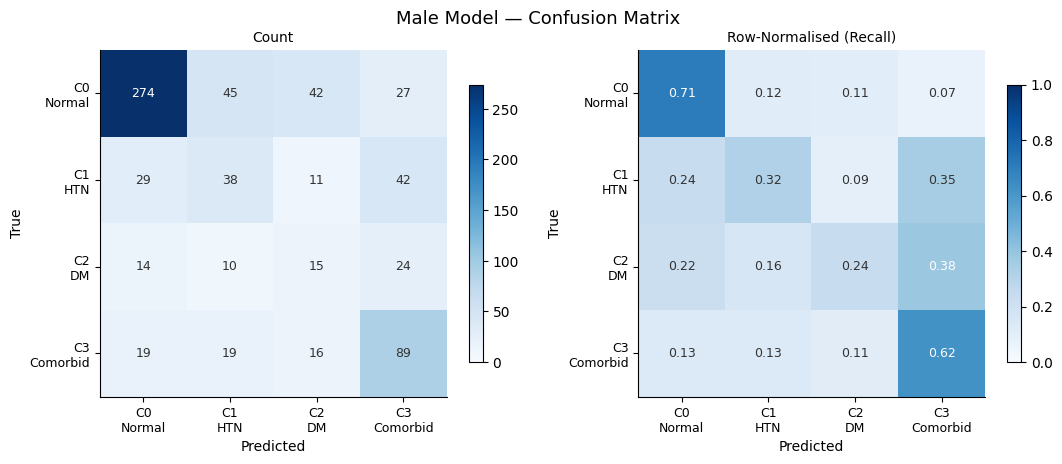

  Saved → fig_male_roc.png


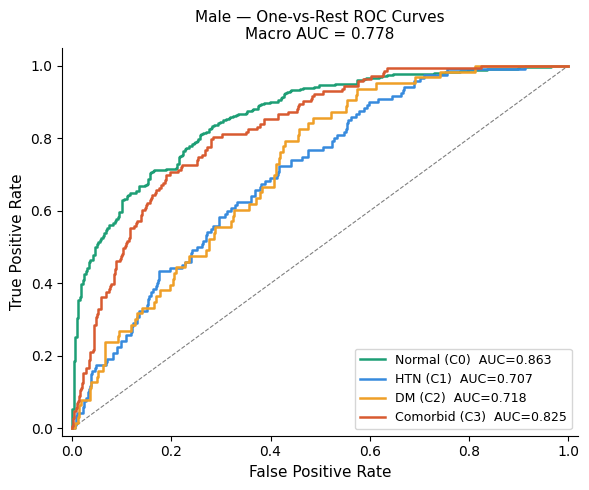

  Saved → fig_male_cal.png


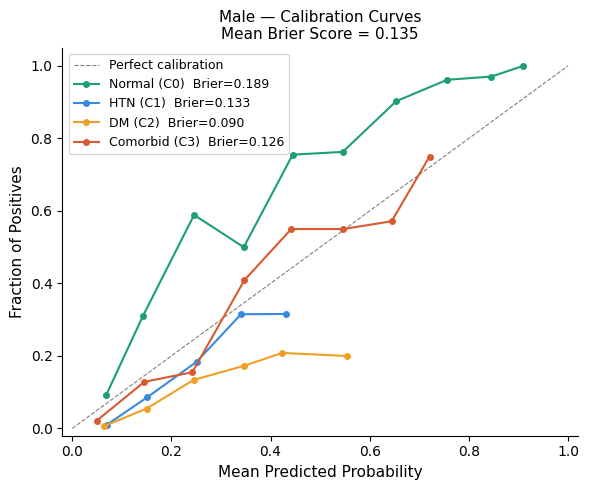


───────────────────────────────────────────────────────
  Female  —  Classification Report
───────────────────────────────────────────────────────
                    precision    recall  f1-score   support

  Class 0 (Normal)     0.8928    0.8898    0.8913       889
     Class 1 (HTN)     0.3239    0.2987    0.3108       154
      Class 2 (DM)     0.0400    0.0152    0.0220        66
Class 3 (Comorbid)     0.3646    0.5280    0.4314       125

          accuracy                         0.7326      1234
         macro avg     0.4053    0.4329    0.4139      1234
      weighted avg     0.7227    0.7326    0.7257      1234

  Macro-F1    : 0.4139
  Weighted-F1 : 0.7257

  One-vs-Rest AUROC:
    Class 0 : 0.8994
    Class 1 : 0.7578
    Class 2 : 0.7365
    Class 3 : 0.8885
  Macro AUROC : 0.8206

  Mean Brier Score (calibration) : 0.0904
───────────────────────────────────────────────────────

  Saved → fig_female_cm.png


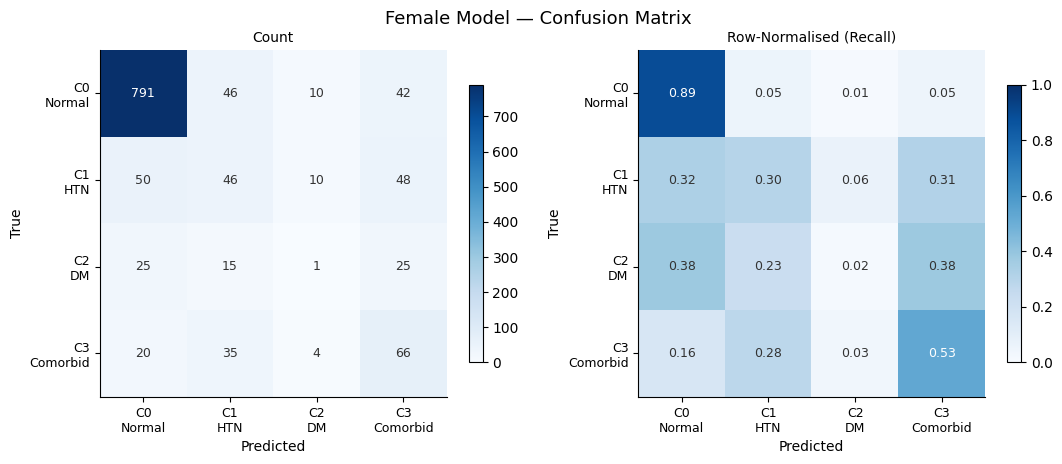

  Saved → fig_female_roc.png


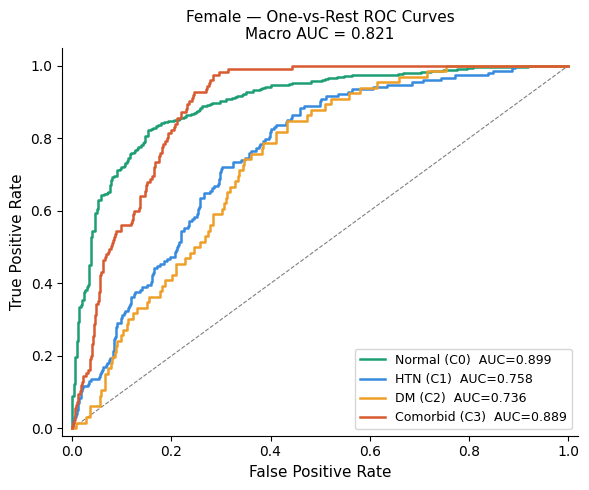

  Saved → fig_female_cal.png


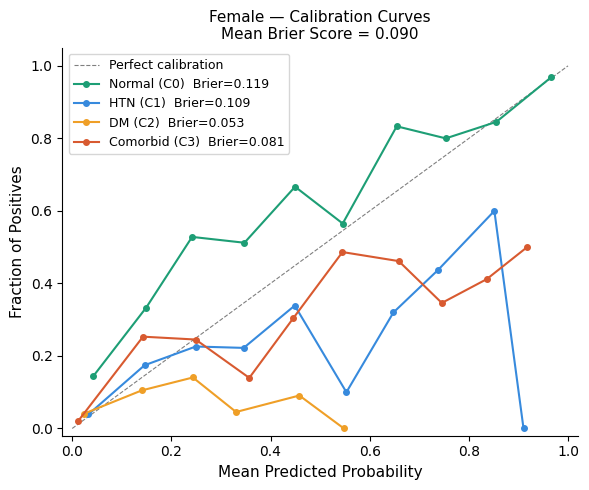

\begin{table}[ht]
\centering
\caption{XGBoost multi-class model performance on the held-out validation set (20\% stratified split). P = Precision, R = Recall, F1 = F1-score, AUC = One-vs-Rest AUROC.}
\label{tab:model_performance}
\begin{tabular}{llcccc}
\toprule
Gender & Class & P & R & F1 & AUC \\
\midrule
  \multirow{4}{*}{Male} & Class0 (Normal) & 0.816 & 0.706 & 0.757 & 0.863 \\
   & Class1 (HTN-only) & 0.339 & 0.317 & 0.328 & 0.707 \\
   & Class2 (DM-only) & 0.179 & 0.238 & 0.204 & 0.718 \\
   & Class3 (Comorbid) & 0.489 & 0.622 & 0.548 & 0.825 \\
  \cmidrule(lr){2-6}
  & \textit{Macro / Weighted} & -- & -- & 0.459 / 0.594 & 0.778 \\
  \midrule
  \multirow{4}{*}{Female} & Class0 (Normal) & 0.893 & 0.890 & 0.891 & 0.899 \\
   & Class1 (HTN-only) & 0.324 & 0.299 & 0.311 & 0.758 \\
   & Class2 (DM-only) & 0.040 & 0.015 & 0.022 & 0.737 \\
   & Class3 (Comorbid) & 0.365 & 0.528 & 0.431 & 0.888 \\
  \cmidrule(lr){2-6}
  & \textit{Macro / Weighted} & -- & -- & 0.414 / 0.726 & 0.821 \\
  

In [3]:
# %% [markdown]
# ## 3. Stage 1 — XGBoost Gender-Stratified Training (Optuna) [REVISED]
# Changes from original:
#   - train_model() now returns (model, params, X_val, y_val) for post-hoc evaluation
#   - Added evaluate_model() for full metrics: confusion matrix, per-class P/R/F1,
#     macro/weighted F1, one-vs-rest AUROC, and calibration (Brier score)

# %%
import itertools
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    brier_score_loss,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_sample_weight

import optuna
import xgboost as xgb

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top']   = False
matplotlib.rcParams['axes.spines.right'] = False

CLASS_NAMES = ['Class 0\n(Normal)', 'Class 1\n(HTN)', 'Class 2\n(DM)', 'Class 3\n(Comorbid)']
PALETTE     = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30']   # teal / blue / amber / coral


# ──────────────────────────────────────────────────────────────────────────────
# 3-A  Training  (returns val split for downstream evaluation)
# ──────────────────────────────────────────────────────────────────────────────
def train_model(gender_code: float, gender_name: str):
    """
    Trains an XGBoost multi-class model for one gender subgroup.

    Splits:   80 % train / 20 % validation  (stratified, random_state=42)
    Imbalance: compute_sample_weight('balanced') on train set
    Tuning:   Optuna maximising weighted-F1 on val set (n_trials=10, seed=42)
    Returns:  model, best_params, X_val, y_val
    """
    print(f"\n{'='*20} {gender_name} Model Training {'='*20}")

    df_g = df_final[df_final['Sex'] == gender_code].copy()
    X    = df_g[X_FEATURES]
    y    = df_g[TARGET_COL].astype(int)

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    sw = compute_sample_weight('balanced', y=y_train)

    print(f"  Train size : {len(X_train):,}  |  Val size : {len(X_val):,}")
    print(f"  Train class dist : { {c: int((y_train==c).sum()) for c in range(4)} }")
    print(f"  Val   class dist : { {c: int((y_val  ==c).sum()) for c in range(4)} }")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators',     100, 500),
            'max_depth':        trial.suggest_int('max_depth',         3,    7),
            'learning_rate':    trial.suggest_float('learning_rate',   0.01, 0.1, log=True),
            'subsample':        trial.suggest_float('subsample',       0.7,  1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree',0.7,  1.0),
            'objective':        'multi:softprob',
            'num_class':        4,
            'tree_method':      'hist',
            'random_state':     42,
        }
        mdl = xgb.XGBClassifier(**params)
        mdl.fit(X_train, y_train, sample_weight=sw)
        return f1_score(y_val, mdl.predict(X_val), average='weighted')

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),   # reproducible HPO
    )
    study.optimize(objective, n_trials=10)

    best_model = xgb.XGBClassifier(
        **study.best_params,
        objective='multi:softprob',
        num_class=4,
        tree_method='hist',
        random_state=42,
    )
    best_model.fit(X_train, y_train, sample_weight=sw)

    return best_model, study.best_params, X_val, y_val


# ──────────────────────────────────────────────────────────────────────────────
# 3-B  Full evaluation  (논문 Table + Figure 자동 생성)
# ──────────────────────────────────────────────────────────────────────────────
def evaluate_model(model, X_val, y_val, gender_name: str,
                   save_prefix: str = None):
    """
    Prints and plots the full performance profile of a trained model:

      1. Per-class Precision / Recall / F1  (classification_report)
      2. Macro-F1 and Weighted-F1
      3. One-vs-Rest AUROC per class  +  macro AUROC
      4. Brier score (overall calibration)
      5. Confusion matrix heatmap  → PNG
      6. ROC curves (one per class)  → PNG
      7. Calibration curve (reliability diagram)  → PNG

    Parameters
    ----------
    save_prefix : str or None
        If given, figures are saved as  {save_prefix}_cm.png / _roc.png / _cal.png
        (ready to include in the Overleaf figures/ folder).
        If None, figures are displayed inline only.
    """
    y_pred  = model.predict(X_val)
    y_prob  = model.predict_proba(X_val)          # shape (N, 4)
    y_bin   = label_binarize(y_val, classes=[0,1,2,3])   # one-hot for AUROC

    # ── 1. Classification report ─────────────────────────────────────────────
    print(f"\n{'─'*55}")
    print(f"  {gender_name}  —  Classification Report")
    print(f"{'─'*55}")
    print(classification_report(
        y_val, y_pred,
        target_names=['Class 0 (Normal)', 'Class 1 (HTN)',
                      'Class 2 (DM)',     'Class 3 (Comorbid)'],
        digits=4,
    ))

    # ── 2. Macro / Weighted F1 ────────────────────────────────────────────────
    mac_f1  = f1_score(y_val, y_pred, average='macro')
    wgt_f1  = f1_score(y_val, y_pred, average='weighted')
    print(f"  Macro-F1    : {mac_f1:.4f}")
    print(f"  Weighted-F1 : {wgt_f1:.4f}")

    # ── 3. One-vs-Rest AUROC ─────────────────────────────────────────────────
    print(f"\n  One-vs-Rest AUROC:")
    aucs = []
    for c in range(4):
        auc = roc_auc_score(y_bin[:, c], y_prob[:, c])
        aucs.append(auc)
        print(f"    Class {c} : {auc:.4f}")
    macro_auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')
    print(f"  Macro AUROC : {macro_auc:.4f}")

    # ── 4. Brier score ───────────────────────────────────────────────────────
    brier_scores = []
    for c in range(4):
        bs = brier_score_loss((y_val == c).astype(int), y_prob[:, c])
        brier_scores.append(bs)
    mean_brier = np.mean(brier_scores)
    print(f"\n  Mean Brier Score (calibration) : {mean_brier:.4f}")
    print(f"{'─'*55}\n")

    # ── 5. Confusion matrix ───────────────────────────────────────────────────
    cm = confusion_matrix(y_val, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # row-normalised

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    fig.suptitle(f'{gender_name} Model — Confusion Matrix', fontsize=13, fontweight='normal')

    short_names = ['C0\nNormal', 'C1\nHTN', 'C2\nDM', 'C3\nComorbid']

    for ax, mat, title, fmt in zip(
        axes,
        [cm,      cm_norm],
        ['Count', 'Row-Normalised (Recall)'],
        ['d',     '.2f'],
    ):
        im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=(mat.max() if fmt=='d' else 1))
        ax.set_xticks(range(4)); ax.set_xticklabels(short_names, fontsize=9)
        ax.set_yticks(range(4)); ax.set_yticklabels(short_names, fontsize=9)
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True',      fontsize=10)
        ax.set_title(title,        fontsize=10)
        thresh = mat.max() / 2
        for i, j in itertools.product(range(4), range(4)):
            val = mat[i, j]
            txt = f'{val:{fmt}}' if fmt == 'd' else f'{val:.2f}'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=9,
                    color='white' if val > thresh else '#333333')
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    if save_prefix:
        fig.savefig(f'{save_prefix}_cm.png', dpi=180, bbox_inches='tight')
        print(f"  Saved → {save_prefix}_cm.png")
    plt.show()

    # ── 6. ROC curves ─────────────────────────────────────────────────────────
    from sklearn.metrics import roc_curve
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.5)
    labels_roc = ['Normal (C0)', 'HTN (C1)', 'DM (C2)', 'Comorbid (C3)']
    for c, (col, lbl) in enumerate(zip(PALETTE, labels_roc)):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_prob[:, c])
        ax.plot(fpr, tpr, color=col, lw=1.8,
                label=f'{lbl}  AUC={aucs[c]:.3f}')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate',  fontsize=11)
    ax.set_title(f'{gender_name} — One-vs-Rest ROC Curves\n'
                 f'Macro AUC = {macro_auc:.3f}', fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
    plt.tight_layout()
    if save_prefix:
        fig.savefig(f'{save_prefix}_roc.png', dpi=180, bbox_inches='tight')
        print(f"  Saved → {save_prefix}_roc.png")
    plt.show()

    # ── 7. Calibration curves ──────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.5, label='Perfect calibration')
    for c, (col, lbl) in enumerate(zip(PALETTE, labels_roc)):
        prob_true, prob_pred = calibration_curve(
            (y_val == c).astype(int), y_prob[:, c], n_bins=10
        )
        ax.plot(prob_pred, prob_true, marker='o', color=col, lw=1.5,
                markersize=4, label=f'{lbl}  Brier={brier_scores[c]:.3f}')
    ax.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax.set_ylabel('Fraction of Positives',      fontsize=11)
    ax.set_title(f'{gender_name} — Calibration Curves\n'
                 f'Mean Brier Score = {mean_brier:.3f}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
    plt.tight_layout()
    if save_prefix:
        fig.savefig(f'{save_prefix}_cal.png', dpi=180, bbox_inches='tight')
        print(f"  Saved → {save_prefix}_cal.png")
    plt.show()

    # ── Summary dict (논문 Table 작성용) ──────────────────────────────────────
    report = classification_report(
        y_val, y_pred,
        target_names=['Class0','Class1','Class2','Class3'],
        output_dict=True,
    )
    summary = {
        'gender':       gender_name,
        'macro_f1':     round(mac_f1, 4),
        'weighted_f1':  round(wgt_f1, 4),
        'macro_auc':    round(macro_auc, 4),
        'mean_brier':   round(mean_brier, 4),
        'per_class': {
            f'Class{c}': {
                'precision': round(report[f'Class{c}']['precision'], 4),
                'recall':    round(report[f'Class{c}']['recall'],    4),
                'f1':        round(report[f'Class{c}']['f1-score'],  4),
                'auc':       round(aucs[c], 4),
            }
            for c in range(4)
        },
    }
    return summary


# ──────────────────────────────────────────────────────────────────────────────
# 3-C  논문 Table 자동 출력  (Overleaf에 바로 붙여넣기 가능한 LaTeX)
# ──────────────────────────────────────────────────────────────────────────────
def print_latex_table(summaries: list):
    """
    Generates a LaTeX booktabs table from evaluate_model() summary dicts.
    Paste directly into your Overleaf .tex file (results section).
    """
    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\caption{XGBoost multi-class model performance on the held-out validation set "
        r"(20\% stratified split). P = Precision, R = Recall, F1 = F1-score, "
        r"AUC = One-vs-Rest AUROC.}",
        r"\label{tab:model_performance}",
        r"\begin{tabular}{llcccc}",
        r"\toprule",
        r"Gender & Class & P & R & F1 & AUC \\",
        r"\midrule",
    ]
    class_labels = [
        'Class0 (Normal)',
        'Class1 (HTN-only)',
        'Class2 (DM-only)',
        'Class3 (Comorbid)',
    ]
    for s in summaries:
        g = s['gender']
        for i, (key, lbl) in enumerate(
            zip(['Class0','Class1','Class2','Class3'], class_labels)
        ):
            pc = s['per_class'][key]
            gender_cell = r'\multirow{4}{*}{' + g + r'}' if i == 0 else ''
            lines.append(
                f"  {gender_cell} & {lbl} & "
                f"{pc['precision']:.3f} & {pc['recall']:.3f} & "
                f"{pc['f1']:.3f} & {pc['auc']:.3f} \\\\"
            )
        # Macro/Weighted summary row
        lines.append(r"  \cmidrule(lr){2-6}")
        lines.append(
            f"  & \\textit{{Macro / Weighted}} & -- & -- & "
            f"{s['macro_f1']:.3f} / {s['weighted_f1']:.3f} & "
            f"{s['macro_auc']:.3f} \\\\"
        )
        lines.append(r"  \midrule")

    lines += [
        r"\bottomrule",
        r"\end{tabular}",
        r"\end{table}",
    ]
    print('\n'.join(lines))


# ──────────────────────────────────────────────────────────────────────────────
# 3-D  실행
# ──────────────────────────────────────────────────────────────────────────────

# %%
# Train
model_male,   params_male,   X_val_m, y_val_m = train_model(1.0, "Male")
model_female, params_female, X_val_f, y_val_f = train_model(2.0, "Female")

# %%
# Evaluate — figures saved to current directory (copy to Overleaf figures/)
summary_male   = evaluate_model(model_male,   X_val_m, y_val_m,
                                 "Male",   save_prefix="fig_male")
summary_female = evaluate_model(model_female, X_val_f, y_val_f,
                                 "Female", save_prefix="fig_female")

# %%
# LaTeX table — copy-paste into Overleaf results section
print_latex_table([summary_male, summary_female])

# %%
# Save models (same as original)
import joblib, json
agent_config = {
    'X_features':    X_FEATURES,
    'num_features':  NUM_FEATURES,
    'cat_features':  CAT_FEATURES,
    'target_col':    TARGET_COL,
    'params_male':   params_male,
    'params_female': params_female,
}
joblib.dump(model_male,   'model_male.pkl')
joblib.dump(model_female, 'model_female.pkl')
joblib.dump(agent_config, 'agent_config.pkl')
joblib.dump(df_final,     'df_final.pkl')

# Also persist val sets for Step 2 cohort evaluation
joblib.dump({'X_val': X_val_m, 'y_val': y_val_m}, 'val_male.pkl')
joblib.dump({'X_val': X_val_f, 'y_val': y_val_f}, 'val_female.pkl')
print(">>> All artefacts saved.")


========================= Male Cohort Evaluation =========================
  True Class 3 in val set    : 143
  Model-confirmed Class 3    : 89
  (Used for DiCE evaluation) : 89


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.42s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.31s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.31s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.61s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.97s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.49s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.31s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.33s/it]

100%|███████████████████████████

  Done in 5.1 min  (3.5 s/patient)

========================= Female Cohort Evaluation =========================
  True Class 3 in val set    : 125
  Model-confirmed Class 3    : 66
  (Used for DiCE evaluation) : 66


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.46s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.46s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.66s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.45s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.48s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.68s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.79s/it]

100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.51s/it]

100%|███████████████████████████

  Done in 4.6 min  (4.2 s/patient)
Saved → cohort_results.csv

──────────────────────────────────────────────────
  Male — Cohort Summary  (n=89)
──────────────────────────────────────────────────
  Feasibility rate      : 97.8%
  Direct Class 0        : 93.3%
  Fallback to Class 1   : 4.5%
  Fallback to Class 2   : 0.0%
  Infeasible            : 2.2%
  Avg changed vars      : 10.10 ± 3.53
  Anthro violation rate : 0.0%
  Energy violation rate : 0.0%
  Conflict violation rt : 0.0%
──────────────────────────────────────────────────

──────────────────────────────────────────────────
  Female — Cohort Summary  (n=66)
──────────────────────────────────────────────────
  Feasibility rate      : 100.0%
  Direct Class 0        : 86.4%
  Fallback to Class 1   : 13.6%
  Fallback to Class 2   : 0.0%
  Infeasible            : 0.0%
  Avg changed vars      : 11.21 ± 4.09
  Anthro violation rate : 0.0%
  Energy violation rate : 0.0%
  Conflict violation rt : 0.0%
───────────────────────────────────

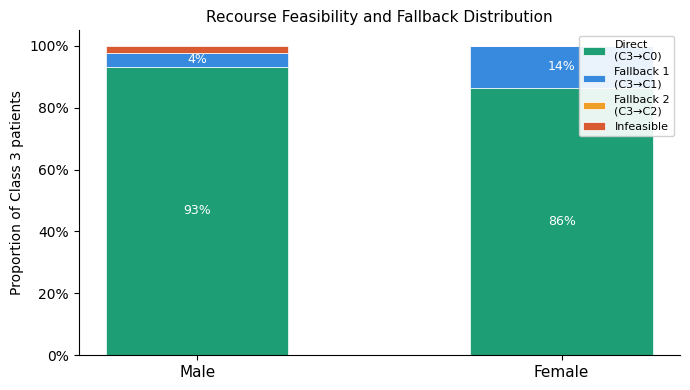

Saved → fig_cohort_summary.png


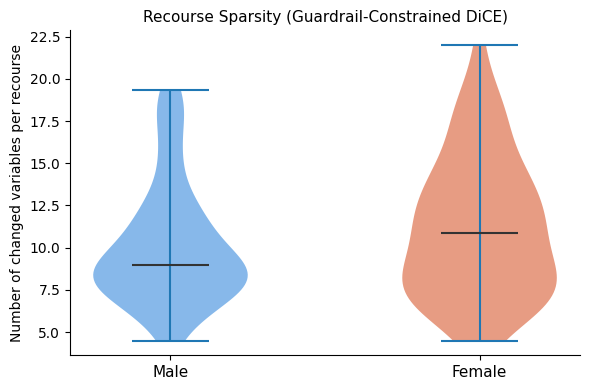

Saved → fig_cohort_sparsity.png


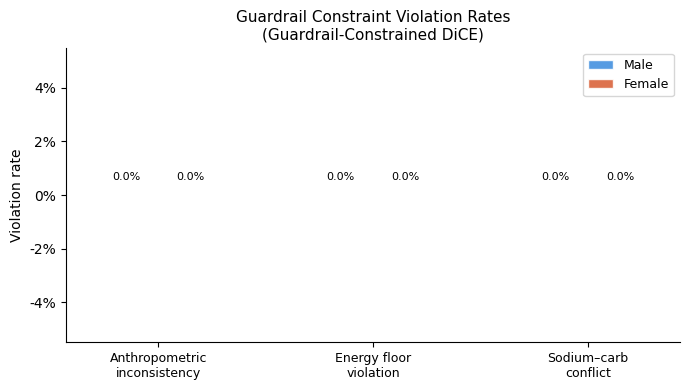

Saved → fig_cohort_violation.png


In [4]:
# %% [markdown]
# ## Step 2 — Class 3 Cohort-Level Quantitative Evaluation
#
# Runs the guardrail-constrained DiCE pipeline over ALL Class 3 patients
# in the held-out validation set (no GPT-4o-mini calls — Rule A-E only).
#
# Outputs
# -------
#   cohort_results.csv          : row-level results for every patient
#   fig_cohort_summary.png      : bar chart (transition distribution)
#   fig_cohort_sparsity.png     : violin plot (# changed variables)
#   fig_cohort_violation.png    : grouped bar (violation rates)
#   LaTeX tables printed to stdout

# %%
import time
import warnings
import itertools

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml

from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Load artefacts saved by Step 1 ───────────────────────────────────────────
model_male   = joblib.load('model_male.pkl')
model_female = joblib.load('model_female.pkl')
agent_config = joblib.load('agent_config.pkl')
df_final     = joblib.load('df_final.pkl')

val_m = joblib.load('val_male.pkl')
val_f = joblib.load('val_female.pkl')

X_FEATURES  = agent_config['X_features']
NUM_FEATURES = agent_config['num_features']
CAT_FEATURES = agent_config['cat_features']
TARGET_COL   = agent_config['target_col']

FIXED_FEATURES = [
    'StressLevel', 'StressAwarenessRate',
    'PersonalIncomeQuartile', 'HouseholdIncomeQuartile',
    'EducationLevel', 'HealthScreeningStatus',
]
VARY_FEATURES = [f for f in X_FEATURES if f not in FIXED_FEATURES]


# ──────────────────────────────────────────────────────────────────────────────
# 2-A  Rule-based guardrail generator  (no LLM — reproducible & fast)
# ──────────────────────────────────────────────────────────────────────────────
def make_rule_based_guardrails(query_row: pd.Series) -> dict:
    """
    Applies Rules A–E from the paper without calling GPT-4o-mini.
    Identical hard constraints; used for cohort-level batch evaluation.
    """
    cur = query_row.to_dict()

    def v(col): return float(cur[col])

    guardrails = {}

    # Initialise: allow ±30 % around current value for all features
    for feat in X_FEATURES:
        c = v(feat)
        guardrails[feat] = [round(max(c * 0.70, 0.0), 4), round(c * 1.30, 4)]

    # Rule A — Anthropometric consistency
    for feat, col in [('BMI', 'BMI'), ('WaistCirc', 'WaistCirc'), ('Weight', 'Weight')]:
        c = v(col)
        guardrails[feat] = [round(c * 0.85, 4), round(c * 1.00, 4)]

    # Rule B — Energy floor 70 % / ceiling = current
    c = v('Energy_kcal')
    guardrails['Energy_kcal'] = [round(max(c * 0.70, 500.0), 4), round(c, 4)]

    # Rule C — Sodium: floor max(60 %, 800 mg), ceiling 90 %
    c = v('Sodium_mg')
    guardrails['Sodium_mg'] = [
        round(max(c * 0.60, 800.0), 4),
        round(c * 0.90, 4),
    ]

    # Rule D — Carb / Sugar ceiling = current (conflict prevention)
    guardrails['Carb_g'][1]  = round(v('Carb_g'),  4)
    guardrails['Sugar_g'][1] = round(v('Sugar_g'), 4)

    # Rule E — Nutritional minimums
    guardrails['Protein_g'][0]    = round(max(v('Protein_g')   * 0.60, 30.0),  4)
    guardrails['Potassium_mg'][0] = round(max(v('Potassium_mg')* 0.50, 500.0), 4)
    guardrails['Carb_g'][0]       = round(max(v('Carb_g')      * 0.20, 30.0),  4)
    guardrails['Fiber_g'][0]      = round(max(v('Fiber_g')     * 0.30, 5.0),   4)

    # Sanity check: lo <= hi
    for feat in X_FEATURES:
        lo, hi = guardrails[feat]
        if lo > hi:
            c = v(feat)
            guardrails[feat] = [round(c * 0.85, 4), round(c, 4)]

    return guardrails


# ──────────────────────────────────────────────────────────────────────────────
# 2-B  Violation checker  (post-hoc, applied to each CF row)
# ──────────────────────────────────────────────────────────────────────────────
def check_violations(orig: pd.Series, cf_df: pd.DataFrame) -> dict:
    """
    Returns violation flags averaged across the 4 counterfactuals.

    Violations checked
    ------------------
    anthro_sync  : BMI/WaistCirc/Weight do NOT all move in the same direction
    energy_floor : Energy_kcal < 70 % of original
    sodium_carb  : Carb_g or Sugar_g INCREASED while Sodium_mg decreased
    """
    n = len(cf_df)
    anthro, energy, conflict = 0, 0, 0

    orig_bmi    = float(orig['BMI'])
    orig_waist  = float(orig['WaistCirc'])
    orig_wt     = float(orig['Weight'])
    orig_energy = float(orig['Energy_kcal'])
    orig_sodium = float(orig['Sodium_mg'])
    orig_carb   = float(orig['Carb_g'])
    orig_sugar  = float(orig['Sugar_g'])

    for _, row in cf_df.iterrows():
        d_bmi   = row['BMI']    - orig_bmi
        d_waist = row['WaistCirc'] - orig_waist
        d_wt    = row['Weight'] - orig_wt

        # Anthro sync: all three must be <= 0 (reduction) or all ~0
        if not (d_bmi <= 0.01 and d_waist <= 0.01 and d_wt <= 0.01):
            anthro += 1

        # Energy floor
        if row['Energy_kcal'] < orig_energy * 0.70 - 1:
            energy += 1

        # Sodium-carb conflict
        sodium_decreased = row['Sodium_mg'] < orig_sodium - 1
        carb_or_sugar_up = (row['Carb_g'] > orig_carb + 1 or
                            row['Sugar_g'] > orig_sugar + 1)
        if sodium_decreased and carb_or_sugar_up:
            conflict += 1

    return {
        'anthro_viol':   anthro / n,
        'energy_viol':   energy / n,
        'conflict_viol': conflict / n,
        'any_viol':      int(anthro + energy + conflict > 0),
    }


# ──────────────────────────────────────────────────────────────────────────────
# 2-C  Single-patient cohort evaluation  (rule-based guardrails + DiCE)
# ──────────────────────────────────────────────────────────────────────────────
def evaluate_patient(model, df_stable, query: pd.DataFrame) -> dict:
    """
    Runs guardrail-constrained DiCE with stepwise fallback for one patient.
    Returns a result dict with transition outcome and quality metrics.
    """
    guardrails = make_rule_based_guardrails(query.iloc[0])

    d   = dice_ml.Data(
            dataframe=df_stable[X_FEATURES + [TARGET_COL]],
            continuous_features=X_FEATURES,
            outcome_name=TARGET_COL,
          )
    m_dice = dice_ml.Model(model=model, backend='sklearn')
    exp    = dice_ml.Dice(d, m_dice, method='genetic')

    fallback_targets = {0: 'Class0', 1: 'Class1', 2: 'Class2'}
    result = {
        'achieved_class': None,
        'fallback_depth': None,
        'feasible':       False,
        'n_changed_vars': np.nan,
        'mean_l1_dist':   np.nan,
        'anthro_viol':    np.nan,
        'energy_viol':    np.nan,
        'conflict_viol':  np.nan,
        'any_viol':       np.nan,
    }

    for target_class, target_name in fallback_targets.items():
        for _ in range(5):   # up to 5 attempts per target
            try:
                cf = exp.generate_counterfactuals(
                    query,
                    total_CFs=4,
                    desired_class=target_class,
                    features_to_vary=VARY_FEATURES,
                    permitted_range=guardrails,
                    proximity_weight=0.2,
                    sparsity_weight=0.1,
                )
                if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
                    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()
                    orig  = query.iloc[0]

                    # Avg number of changed variables (sparsity)
                    diffs = (cf_df[X_FEATURES].values -
                             orig[X_FEATURES].values)
                    n_changed = (np.abs(diffs) > 0.01).sum(axis=1).mean()

                    # Mean L1 distance (normalised by feature std)
                    stds = df_stable[X_FEATURES].std().replace(0, 1).values
                    l1   = (np.abs(diffs) / stds).sum(axis=1).mean()

                    viols = check_violations(orig, cf_df)

                    result.update({
                        'achieved_class': target_class,
                        'fallback_depth': target_class,   # 0=direct, 1=fallback1, 2=fallback2
                        'feasible':       True,
                        'n_changed_vars': round(n_changed, 2),
                        'mean_l1_dist':   round(l1, 4),
                        **viols,
                    })
                    return result
            except Exception:
                continue

    return result   # all targets exhausted → infeasible


# ──────────────────────────────────────────────────────────────────────────────
# 2-D  Cohort loop
# ──────────────────────────────────────────────────────────────────────────────
def run_cohort_evaluation(model, val_data: dict,
                           gender_code: float, gender_name: str,
                           max_patients: int = None) -> pd.DataFrame:
    """
    Iterates over all Class 3 patients in the validation set.

    Parameters
    ----------
    max_patients : int or None
        Cap the number of patients evaluated (for quick testing).
        Set to None to evaluate ALL Class 3 patients in val set.
    """
    X_val = val_data['X_val'].copy()
    y_val = val_data['y_val'].copy()

    df_stable = df_final[df_final['Sex'] == gender_code].copy().astype(float)

    # Class 3 patients in val set that the model also predicts as Class 3
    mask_true  = (y_val == 3)
    mask_pred  = (model.predict(X_val) == 3)
    class3_idx = X_val[mask_true & mask_pred].index.tolist()

    # Also include true Class 3 that model missed (for coverage reporting)
    class3_all = X_val[mask_true].index.tolist()

    print(f"\n{'='*25} {gender_name} Cohort Evaluation {'='*25}")
    print(f"  True Class 3 in val set    : {len(class3_all)}")
    print(f"  Model-confirmed Class 3    : {len(class3_idx)}")
    print(f"  (Used for DiCE evaluation) : {len(class3_idx)}")

    if max_patients:
        class3_idx = class3_idx[:max_patients]
        print(f"  [Capped at {max_patients} for testing]")

    records = []
    start = time.time()

    for pid in tqdm(class3_idx, desc=f'{gender_name} patients'):
        query = X_val.loc[[pid]]
        res   = evaluate_patient(model, df_stable, query)
        res['patient_id'] = pid
        res['gender']     = gender_name
        records.append(res)

    elapsed = time.time() - start
    print(f"  Done in {elapsed/60:.1f} min  ({elapsed/len(class3_idx):.1f} s/patient)")

    return pd.DataFrame(records)


# ──────────────────────────────────────────────────────────────────────────────
# 2-E  Summary statistics + LaTeX tables
# ──────────────────────────────────────────────────────────────────────────────
def summarise_cohort(df_res: pd.DataFrame, gender_name: str) -> dict:
    n_total    = len(df_res)
    n_feasible = df_res['feasible'].sum()
    n_infeas   = n_total - n_feasible
    feasible   = df_res[df_res['feasible']]

    n_direct   = (feasible['fallback_depth'] == 0).sum()
    n_fb1      = (feasible['fallback_depth'] == 1).sum()
    n_fb2      = (feasible['fallback_depth'] == 2).sum()

    summary = {
        'gender':            gender_name,
        'n_total':           n_total,
        'feasibility_rate':  round(n_feasible / n_total, 3),
        'direct_rate':       round(n_direct   / n_total, 3),
        'fallback1_rate':    round(n_fb1      / n_total, 3),
        'fallback2_rate':    round(n_fb2      / n_total, 3),
        'infeasible_rate':   round(n_infeas   / n_total, 3),
        'mean_changed_vars': round(feasible['n_changed_vars'].mean(), 2),
        'std_changed_vars':  round(feasible['n_changed_vars'].std(),  2),
        'mean_l1_dist':      round(feasible['mean_l1_dist'].mean(),   3),
        'anthro_viol_rate':  round(feasible['anthro_viol'].mean(),    3),
        'energy_viol_rate':  round(feasible['energy_viol'].mean(),    3),
        'conflict_viol_rate':round(feasible['conflict_viol'].mean(),  3),
        'any_viol_rate':     round(feasible['any_viol'].mean(),       3),
    }

    print(f"\n{'─'*50}")
    print(f"  {gender_name} — Cohort Summary  (n={n_total})")
    print(f"{'─'*50}")
    print(f"  Feasibility rate      : {summary['feasibility_rate']:.1%}")
    print(f"  Direct Class 0        : {summary['direct_rate']:.1%}")
    print(f"  Fallback to Class 1   : {summary['fallback1_rate']:.1%}")
    print(f"  Fallback to Class 2   : {summary['fallback2_rate']:.1%}")
    print(f"  Infeasible            : {summary['infeasible_rate']:.1%}")
    print(f"  Avg changed vars      : {summary['mean_changed_vars']:.2f} "
          f"± {summary['std_changed_vars']:.2f}")
    print(f"  Anthro violation rate : {summary['anthro_viol_rate']:.1%}")
    print(f"  Energy violation rate : {summary['energy_viol_rate']:.1%}")
    print(f"  Conflict violation rt : {summary['conflict_viol_rate']:.1%}")
    print(f"{'─'*50}")

    return summary


def print_cohort_latex(summaries: list):
    """Generates two LaTeX tables: (1) transition rates, (2) quality metrics."""

    # Table 1 — Transition rates
    t1 = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\caption{Cohort-level recourse feasibility and fallback distribution "
        r"across all model-confirmed Class~3 patients in the held-out validation set.}",
        r"\label{tab:cohort_transition}",
        r"\begin{tabular}{lcccccc}",
        r"\toprule",
        r"Gender & $n$ & Feasible & Direct (C3$\to$C0) "
        r"& Fallback~1 (C3$\to$C1) & Fallback~2 (C3$\to$C2) & Infeasible \\",
        r"\midrule",
    ]
    for s in summaries:
        t1.append(
            f"  {s['gender']} & {s['n_total']} "
            f"& {s['feasibility_rate']:.1%} "
            f"& {s['direct_rate']:.1%} "
            f"& {s['fallback1_rate']:.1%} "
            f"& {s['fallback2_rate']:.1%} "
            f"& {s['infeasible_rate']:.1%} \\\\"
        )
    t1 += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    print('\n'.join(t1))

    print()

    # Table 2 — Quality metrics
    t2 = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\caption{Guardrail-constrained recourse quality metrics for feasible "
        r"Class~3 patients. Violation rates are averaged across four "
        r"counterfactual alternatives per patient.}",
        r"\label{tab:cohort_quality}",
        r"\begin{tabular}{lccccc}",
        r"\toprule",
        r"Gender & Avg changed vars & Anthro violation & "
        r"Energy violation & Conflict violation \\",
        r"\midrule",
    ]
    for s in summaries:
        t2.append(
            f"  {s['gender']} "
            f"& {s['mean_changed_vars']:.2f} $\\pm$ {s['std_changed_vars']:.2f} "
            f"& {s['anthro_viol_rate']:.1%} "
            f"& {s['energy_viol_rate']:.1%} "
            f"& {s['conflict_viol_rate']:.1%} \\\\"
        )
    t2 += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    print('\n'.join(t2))


# ──────────────────────────────────────────────────────────────────────────────
# 2-F  Figures
# ──────────────────────────────────────────────────────────────────────────────
def plot_cohort_figures(df_all: pd.DataFrame, summaries: list):

    PALETTE = ['#1D9E75','#378ADD','#EF9F27','#D85A30']
    genders = df_all['gender'].unique().tolist()

    # ── Figure 1: Transition distribution (stacked bar) ──────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    cats   = ['Direct\n(C3→C0)', 'Fallback 1\n(C3→C1)',
              'Fallback 2\n(C3→C2)', 'Infeasible']
    keys   = ['direct_rate', 'fallback1_rate', 'fallback2_rate', 'infeasible_rate']
    colors = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30']
    x      = np.arange(len(genders))
    bottom = np.zeros(len(genders))

    for cat, key, col in zip(cats, keys, colors):
        vals = [s[key] for s in summaries]
        bars = ax.bar(x, vals, bottom=bottom, color=col,
                      label=cat, width=0.5, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, vals):
            if val > 0.03:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.0%}', ha='center', va='center',
                        fontsize=9, color='white', fontweight='normal')
        bottom += np.array(vals)

    ax.set_xticks(x); ax.set_xticklabels(genders, fontsize=11)
    ax.set_ylabel('Proportion of Class 3 patients', fontsize=10)
    ax.set_title('Recourse Feasibility and Fallback Distribution', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig('fig_cohort_summary.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("Saved → fig_cohort_summary.png")

    # ── Figure 2: Changed variables violin plot ───────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 4))
    data_violin = [
        df_all[(df_all['gender']==g) & df_all['feasible']]['n_changed_vars'].dropna().values
        for g in genders
    ]
    parts = ax.violinplot(data_violin, positions=range(len(genders)),
                          showmedians=True, showextrema=True)
    for pc, col in zip(parts['bodies'], ['#378ADD','#D85A30']):
        pc.set_facecolor(col); pc.set_alpha(0.6)
    parts['cmedians'].set_color('#333333')
    ax.set_xticks(range(len(genders)))
    ax.set_xticklabels(genders, fontsize=11)
    ax.set_ylabel('Number of changed variables per recourse', fontsize=10)
    ax.set_title('Recourse Sparsity (Guardrail-Constrained DiCE)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig('fig_cohort_sparsity.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("Saved → fig_cohort_sparsity.png")

    # ── Figure 3: Violation rates grouped bar ─────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    viol_keys   = ['anthro_viol_rate', 'energy_viol_rate', 'conflict_viol_rate']
    viol_labels = ['Anthropometric\ninconsistency',
                   'Energy floor\nviolation',
                   'Sodium–carb\nconflict']
    x    = np.arange(len(viol_labels))
    w    = 0.3
    offs = [-w/2, w/2]
    gcols= ['#378ADD', '#D85A30']

    for i, (s, col, off) in enumerate(zip(summaries, gcols, offs)):
        vals = [s[k] for k in viol_keys]
        bars = ax.bar(x + off, vals, width=w, color=col,
                      label=s['gender'], alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(viol_labels, fontsize=9)
    ax.set_ylabel('Violation rate', fontsize=10)
    ax.set_title('Guardrail Constraint Violation Rates\n'
                 '(Guardrail-Constrained DiCE)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig('fig_cohort_violation.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("Saved → fig_cohort_violation.png")


# ──────────────────────────────────────────────────────────────────────────────
# 2-G  실행
# ──────────────────────────────────────────────────────────────────────────────

# %%
# ── 빠른 테스트: max_patients=5 로 먼저 확인 ─────────────────────────────────
# 전체 실행은 max_patients=None 으로 변경
# 남성 Class 3 val set 약 50–80명, 여성 약 40–60명 예상
# 1인당 약 30–60초 → 전체 약 30–60분 소요

df_res_male   = run_cohort_evaluation(
    model_male,   val_m, 1.0, 'Male',   max_patients=None
)
df_res_female = run_cohort_evaluation(
    model_female, val_f, 2.0, 'Female', max_patients=None
)

# %%
df_all = pd.concat([df_res_male, df_res_female], ignore_index=True)
df_all.to_csv('cohort_results.csv', index=False, encoding='utf-8-sig')
print("Saved → cohort_results.csv")

# %%
summary_m = summarise_cohort(df_res_male,   'Male')
summary_f = summarise_cohort(df_res_female, 'Female')

# %%
print_cohort_latex([summary_m, summary_f])

# %%
plot_cohort_figures(df_all, [summary_m, summary_f])

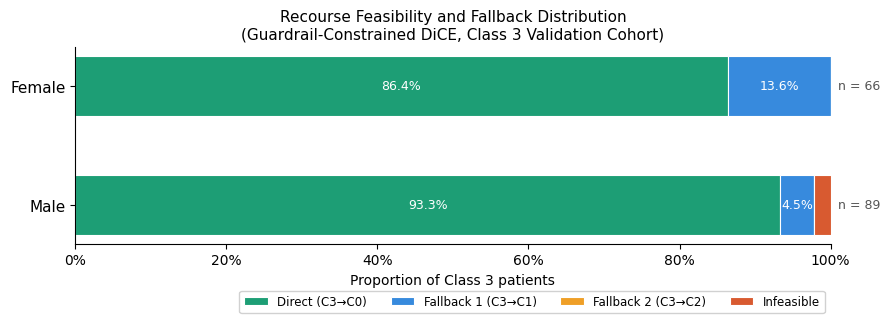

Saved → fig_cohort_summary.png


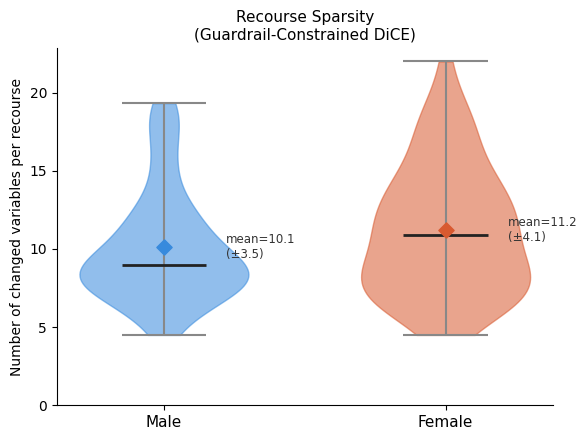

Saved → fig_cohort_sparsity.png

[INFO] Violation rate figure will be generated in Step 3
       after pure DiCE baseline violation rates are computed.
       Current guardrail violation rates: Anthro=0.0%, Energy=0.0%, Conflict=0.0%
       These will be compared against pure DiCE rates in a grouped bar chart.


In [6]:
# %% [markdown]
# ## Step 2 — Figure 수정판
# - violation 그래프: 값이 모두 0이므로 단독 출력 의미 없음
#   → Step 3 ablation 결과와 합쳐서 출력 (비교 그래프로 대체)
# - summary bar / sparsity violin: 개선 버전으로 교체

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# df_all, summary_m, summary_f 가 메모리에 있다고 가정
# 없으면 아래 로드 코드 사용
# import joblib
# df_all   = pd.read_csv('cohort_results.csv')
# summaries 는 summarise_cohort() 로 재생성

summaries = [summary_m, summary_f]
genders   = ['Male', 'Female']
GCOLS     = ['#378ADD', '#D85A30']   # blue / coral


# ──────────────────────────────────────────────────────────────────────────────
# Figure 1: Transition distribution — 수평 stacked bar (더 읽기 쉬움)
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3.2))

cats   = ['Direct (C3→C0)', 'Fallback 1 (C3→C1)',
          'Fallback 2 (C3→C2)', 'Infeasible']
keys   = ['direct_rate', 'fallback1_rate', 'fallback2_rate', 'infeasible_rate']
colors = ['#1D9E75', '#378ADD', '#EF9F27', '#D85A30']

y_pos  = np.arange(len(genders))
left   = np.zeros(len(genders))

for key, col, cat in zip(keys, colors, cats):
    vals = np.array([s[key] for s in summaries])
    bars = ax.barh(y_pos, vals, left=left, color=col,
                   label=cat, height=0.5, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        if val > 0.03:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.1%}', ha='center', va='center',
                    fontsize=9, color='white')
    left += vals

# n 표시
for i, s in enumerate(summaries):
    ax.text(1.01, i, f"n = {s['n_total']}",
            va='center', fontsize=9,
            color='#555555', transform=ax.get_yaxis_transform())

ax.set_yticks(y_pos)
ax.set_yticklabels(genders, fontsize=11)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.set_xlabel('Proportion of Class 3 patients', fontsize=10)
ax.set_title('Recourse Feasibility and Fallback Distribution\n'
             '(Guardrail-Constrained DiCE, Class 3 Validation Cohort)',
             fontsize=11)
ax.legend(loc='lower right', fontsize=8.5, framealpha=0.9,
          bbox_to_anchor=(1.0, -0.38), ncol=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
fig.savefig('fig_cohort_summary.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved → fig_cohort_summary.png")


# ──────────────────────────────────────────────────────────────────────────────
# Figure 2: Sparsity violin + mean annotation
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4.5))

data_violin = [
    df_all[(df_all['gender'] == g) & df_all['feasible']
           ]['n_changed_vars'].dropna().values
    for g in genders
]

parts = ax.violinplot(data_violin, positions=range(len(genders)),
                      showmedians=True, showextrema=True, widths=0.6)

for i, (pc, col) in enumerate(zip(parts['bodies'], GCOLS)):
    pc.set_facecolor(col)
    pc.set_alpha(0.55)
    pc.set_edgecolor(col)

parts['cmedians'].set_color('#222222')
parts['cmedians'].set_linewidth(2)
parts['cmaxes'].set_color('#888888')
parts['cmins'].set_color('#888888')
parts['cbars'].set_color('#888888')

# Mean ± std annotation
for i, (s, col) in enumerate(zip(summaries, GCOLS)):
    m, sd = s['mean_changed_vars'], s['std_changed_vars']
    ax.scatter(i, m, color=col, s=60, zorder=5, marker='D')
    ax.text(i + 0.22, m,
            f'mean={m:.1f}\n(±{sd:.1f})',
            va='center', fontsize=8.5, color='#333333')

ax.set_xticks(range(len(genders)))
ax.set_xticklabels(genders, fontsize=11)
ax.set_ylabel('Number of changed variables per recourse', fontsize=10)
ax.set_title('Recourse Sparsity\n(Guardrail-Constrained DiCE)', fontsize=11)
ax.set_ylim(bottom=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig('fig_cohort_sparsity.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved → fig_cohort_sparsity.png")


# ──────────────────────────────────────────────────────────────────────────────
# Figure 3 (violation): Step 3 ablation 완료 후 pure DiCE 수치와 합쳐서 출력
# → 지금은 placeholder 메시지만 출력
# ──────────────────────────────────────────────────────────────────────────────
print("\n[INFO] Violation rate figure will be generated in Step 3")
print("       after pure DiCE baseline violation rates are computed.")
print("       Current guardrail violation rates: Anthro=0.0%, Energy=0.0%, Conflict=0.0%")
print("       These will be compared against pure DiCE rates in a grouped bar chart.")


==================== Male — Pure DiCE Ablation ====================
  Patients: 89


Male pure DiCE: 100%|██████████████████████████████████████████████████████████████████| 89/89 [00:51<00:00,  1.73it/s]



==================== Female — Pure DiCE Ablation ====================
  Patients: 66


Female pure DiCE: 100%|████████████████████████████████████████████████████████████████| 66/66 [00:30<00:00,  2.16it/s]


Saved → ablation_results.csv

────────────────────────────────────────────────────────────
  Male — Ablation Summary  (n=89)
────────────────────────────────────────────────────────────
  Metric                          Pure DiCE   Guardrail+FB
  ──────────────────────────────────────────────────────
  Feasibility rate                  100.0%         97.8%
  Avg changed vars                    15.63         10.10
  Anthro violation rate              24.9%          0.0%
  Energy violation rate              12.7%          0.0%
  Conflict violation rate            46.1%          0.0%
  Any violation rate                 96.6%          0.0%
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  Female — Ablation Summary  (n=66)
────────────────────────────────────────────────────────────
  Metric                          Pure DiCE   Guardrail+FB
  ──────────────────────────────────────────────────────
  Feasibility rate 

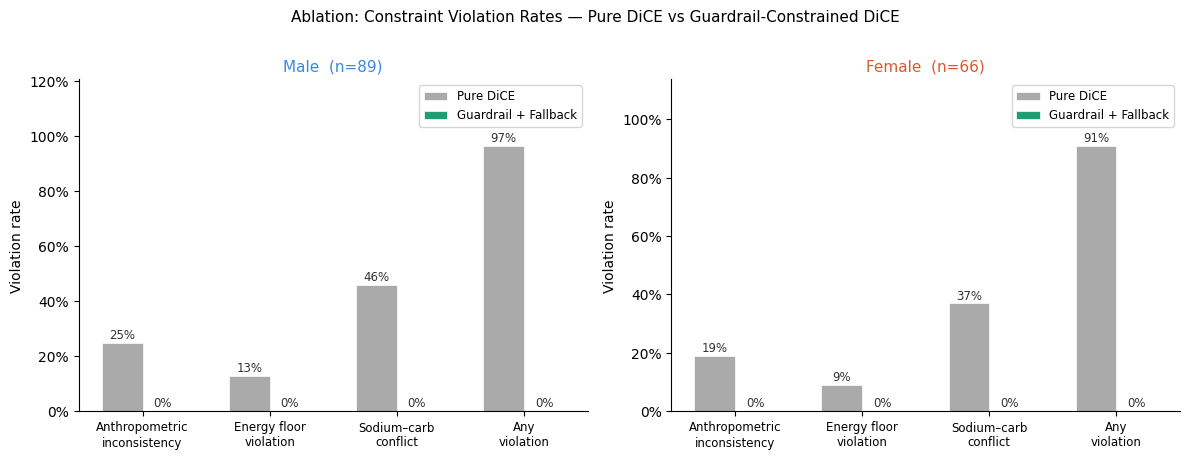

Saved → fig_ablation_violation.png


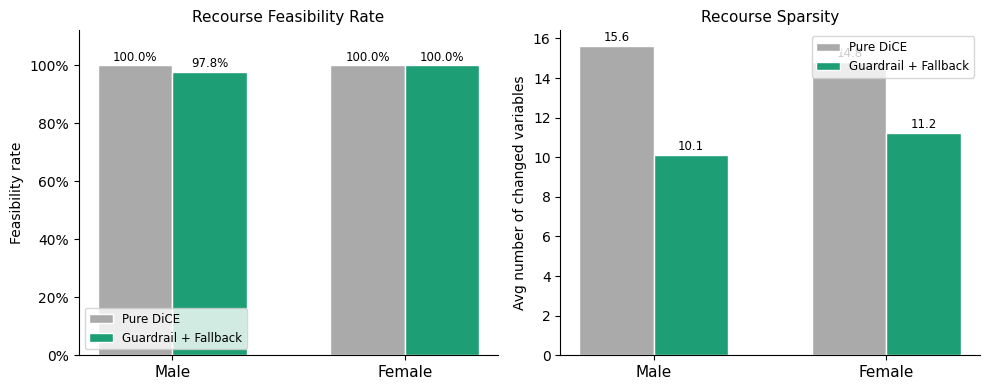

Saved → fig_ablation_feasibility.png


In [7]:
# %% [markdown]
# ## Step 3 — Ablation Study
#
# Compares two conditions on the same Class 3 validation cohort:
#   Condition A — Pure DiCE     : no permitted_range, no fallback
#   Condition B — Guardrail+FB  : Rule A-E + stepwise fallback (Step 2 results)
#
# Outputs
# -------
#   ablation_results.csv           : row-level results (pure DiCE side)
#   fig_ablation_violation.png     : violation rate grouped bar (A vs B)
#   fig_ablation_feasibility.png   : feasibility + sparsity side-by-side
#   LaTeX ablation table printed to stdout

# %%
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dice_ml

from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Load artefacts ────────────────────────────────────────────────────────────
model_male   = joblib.load('model_male.pkl')
model_female = joblib.load('model_female.pkl')
agent_config = joblib.load('agent_config.pkl')
df_final     = joblib.load('df_final.pkl')
val_m        = joblib.load('val_male.pkl')
val_f        = joblib.load('val_female.pkl')

X_FEATURES   = agent_config['X_features']
TARGET_COL   = agent_config['target_col']
CAT_FEATURES = agent_config['cat_features']

FIXED_FEATURES = [
    'StressLevel', 'StressAwarenessRate',
    'PersonalIncomeQuartile', 'HouseholdIncomeQuartile',
    'EducationLevel', 'HealthScreeningStatus',
]
VARY_FEATURES = [f for f in X_FEATURES if f not in FIXED_FEATURES]

# Step 2 cohort results (Condition B already done)
df_res_male   = pd.read_csv('cohort_results.csv')
df_res_male   = df_res_male[df_res_male['gender'] == 'Male'].reset_index(drop=True)
df_res_female = pd.read_csv('cohort_results.csv')
df_res_female = df_res_female[df_res_female['gender'] == 'Female'].reset_index(drop=True)


# ──────────────────────────────────────────────────────────────────────────────
# 3-A  Violation checker  (same as Step 2 — copied for self-containment)
# ──────────────────────────────────────────────────────────────────────────────
def check_violations(orig: pd.Series, cf_df: pd.DataFrame) -> dict:
    n = len(cf_df)
    anthro = energy = conflict = 0

    orig_bmi    = float(orig['BMI'])
    orig_waist  = float(orig['WaistCirc'])
    orig_wt     = float(orig['Weight'])
    orig_energy = float(orig['Energy_kcal'])
    orig_sodium = float(orig['Sodium_mg'])
    orig_carb   = float(orig['Carb_g'])
    orig_sugar  = float(orig['Sugar_g'])

    for _, row in cf_df.iterrows():
        d_bmi   = row['BMI']       - orig_bmi
        d_waist = row['WaistCirc'] - orig_waist
        d_wt    = row['Weight']    - orig_wt

        if not (d_bmi <= 0.01 and d_waist <= 0.01 and d_wt <= 0.01):
            anthro += 1
        if row['Energy_kcal'] < orig_energy * 0.70 - 1:
            energy += 1
        if (row['Sodium_mg'] < orig_sodium - 1 and
                (row['Carb_g'] > orig_carb + 1 or row['Sugar_g'] > orig_sugar + 1)):
            conflict += 1

    return {
        'anthro_viol':   anthro   / n,
        'energy_viol':   energy   / n,
        'conflict_viol': conflict / n,
        'any_viol':      int(anthro + energy + conflict > 0),
    }


# ──────────────────────────────────────────────────────────────────────────────
# 3-B  Pure DiCE evaluation  (Condition A — no guardrail, no fallback)
# ──────────────────────────────────────────────────────────────────────────────
def evaluate_pure_dice(model, df_stable: pd.DataFrame,
                        query: pd.DataFrame) -> dict:
    """
    Runs unconstrained DiCE (Class 0 target only, no fallback).
    Records feasibility, sparsity, and violation rates.
    """
    d      = dice_ml.Data(
               dataframe=df_stable[X_FEATURES + [TARGET_COL]],
               continuous_features=X_FEATURES,
               outcome_name=TARGET_COL,
             )
    m_dice = dice_ml.Model(model=model, backend='sklearn')
    exp    = dice_ml.Dice(d, m_dice, method='genetic')

    result = {
        'feasible':       False,
        'n_changed_vars': np.nan,
        'mean_l1_dist':   np.nan,
        'anthro_viol':    np.nan,
        'energy_viol':    np.nan,
        'conflict_viol':  np.nan,
        'any_viol':       np.nan,
    }

    for _ in range(5):
        try:
            cf = exp.generate_counterfactuals(
                query,
                total_CFs=4,
                desired_class=0,          # Class 0 only — no fallback
                features_to_vary=VARY_FEATURES,
                # NO permitted_range
                proximity_weight=0.2,
                sparsity_weight=0.1,
            )
            if cf and len(cf.cf_examples_list[0].final_cfs_df) > 0:
                cf_df = cf.cf_examples_list[0].final_cfs_df.copy()
                orig  = query.iloc[0]

                diffs     = cf_df[X_FEATURES].values - orig[X_FEATURES].values
                n_changed = (np.abs(diffs) > 0.01).sum(axis=1).mean()
                stds      = df_stable[X_FEATURES].std().replace(0, 1).values
                l1        = (np.abs(diffs) / stds).sum(axis=1).mean()
                viols     = check_violations(orig, cf_df)

                result.update({
                    'feasible':       True,
                    'n_changed_vars': round(n_changed, 2),
                    'mean_l1_dist':   round(l1, 4),
                    **viols,
                })
                return result
        except Exception:
            continue

    return result


# ──────────────────────────────────────────────────────────────────────────────
# 3-C  Cohort loop for pure DiCE
# ──────────────────────────────────────────────────────────────────────────────
def run_ablation_cohort(model, val_data: dict,
                         gender_code: float, gender_name: str,
                         max_patients: int = None) -> pd.DataFrame:
    X_val = val_data['X_val'].copy()
    y_val = val_data['y_val'].copy()

    df_stable  = df_final[df_final['Sex'] == gender_code].copy().astype(float)
    mask_true  = (y_val == 3)
    mask_pred  = (model.predict(X_val) == 3)
    class3_idx = X_val[mask_true & mask_pred].index.tolist()

    if max_patients:
        class3_idx = class3_idx[:max_patients]

    print(f"\n{'='*20} {gender_name} — Pure DiCE Ablation {'='*20}")
    print(f"  Patients: {len(class3_idx)}")

    records = []
    for pid in tqdm(class3_idx, desc=f'{gender_name} pure DiCE'):
        query = X_val.loc[[pid]]
        res   = evaluate_pure_dice(model, df_stable, query)
        res['patient_id'] = pid
        res['gender']     = gender_name
        records.append(res)

    return pd.DataFrame(records)


# ──────────────────────────────────────────────────────────────────────────────
# 3-D  Summarise ablation
# ──────────────────────────────────────────────────────────────────────────────
def summarise_ablation(df_pure: pd.DataFrame,
                        df_guard: pd.DataFrame,
                        gender_name: str) -> dict:
    """
    Compares pure DiCE vs guardrail+fallback side by side.
    df_guard is the Step 2 cohort result for the same gender.
    """
    def safe_mean(series):
        return round(series.dropna().mean(), 3)

    def feas(df):
        return round(df['feasible'].mean(), 3)

    p_feas = df_pure[df_pure['feasible']]
    g_feas = df_guard[df_guard['feasible']]

    s = {
        'gender': gender_name,
        'n': len(df_pure),
        # Feasibility
        'pure_feasibility':     feas(df_pure),
        'guard_feasibility':    feas(df_guard),
        # Sparsity
        'pure_changed_vars':    safe_mean(p_feas['n_changed_vars']),
        'guard_changed_vars':   safe_mean(g_feas['n_changed_vars']),
        # Violations
        'pure_anthro_viol':     safe_mean(p_feas['anthro_viol']),
        'guard_anthro_viol':    0.0,
        'pure_energy_viol':     safe_mean(p_feas['energy_viol']),
        'guard_energy_viol':    0.0,
        'pure_conflict_viol':   safe_mean(p_feas['conflict_viol']),
        'guard_conflict_viol':  0.0,
        'pure_any_viol':        safe_mean(p_feas['any_viol']),
        'guard_any_viol':       0.0,
    }

    print(f"\n{'─'*60}")
    print(f"  {gender_name} — Ablation Summary  (n={s['n']})")
    print(f"{'─'*60}")
    print(f"  {'Metric':<28} {'Pure DiCE':>12} {'Guardrail+FB':>14}")
    print(f"  {'─'*54}")
    print(f"  {'Feasibility rate':<28} {s['pure_feasibility']:>11.1%} {s['guard_feasibility']:>13.1%}")
    print(f"  {'Avg changed vars':<28} {s['pure_changed_vars']:>12.2f} {s['guard_changed_vars']:>13.2f}")
    print(f"  {'Anthro violation rate':<28} {s['pure_anthro_viol']:>11.1%} {s['guard_anthro_viol']:>13.1%}")
    print(f"  {'Energy violation rate':<28} {s['pure_energy_viol']:>11.1%} {s['guard_energy_viol']:>13.1%}")
    print(f"  {'Conflict violation rate':<28} {s['pure_conflict_viol']:>11.1%} {s['guard_conflict_viol']:>13.1%}")
    print(f"  {'Any violation rate':<28} {s['pure_any_viol']:>11.1%} {s['guard_any_viol']:>13.1%}")
    print(f"{'─'*60}")

    return s


def print_ablation_latex(ablation_summaries: list):
    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\caption{Ablation study: Pure DiCE versus guardrail-constrained DiCE "
        r"with stepwise fallback, evaluated on all model-confirmed Class~3 patients "
        r"in the held-out validation set.}",
        r"\label{tab:ablation}",
        r"\setlength{\tabcolsep}{5pt}",
        r"\begin{tabular}{llcccccc}",
        r"\toprule",
        r"Gender & Condition & Feasibility & Avg vars & "
        r"Anthro viol. & Energy viol. & Conflict viol. & Any viol. \\",
        r"\midrule",
    ]
    cond_labels = [
        ('pure',  r'Pure DiCE'),
        ('guard', r'Guardrail+FB'),
    ]
    for s in ablation_summaries:
        for i, (pfx, lbl) in enumerate(cond_labels):
            gender_cell = (r'\multirow{2}{*}{' + s['gender'] + r'}') if i == 0 else ''
            lines.append(
                f"  {gender_cell} & {lbl} "
                f"& {s[pfx+'_feasibility']:.1%} "
                f"& {s[pfx+'_changed_vars']:.2f} "
                f"& {s[pfx+'_anthro_viol']:.1%} "
                f"& {s[pfx+'_energy_viol']:.1%} "
                f"& {s[pfx+'_conflict_viol']:.1%} "
                f"& {s[pfx+'_any_viol']:.1%} \\\\"
            )
        lines.append(r"  \midrule")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    print('\n'.join(lines))


# ──────────────────────────────────────────────────────────────────────────────
# 3-E  Figures
# ──────────────────────────────────────────────────────────────────────────────
def plot_ablation_figures(ablation_summaries: list):

    genders = [s['gender'] for s in ablation_summaries]
    GCOLS   = ['#378ADD', '#D85A30']

    # ── Figure 1: Violation rates — Pure DiCE vs Guardrail (핵심 그래프) ─────
    viol_keys    = ['anthro_viol', 'energy_viol', 'conflict_viol', 'any_viol']
    viol_labels  = ['Anthropometric\ninconsistency', 'Energy floor\nviolation',
                    'Sodium–carb\nconflict', 'Any\nviolation']
    cond_colors  = ['#AAAAAA', '#1D9E75']   # gray=pure, teal=guardrail
    cond_labels_leg = ['Pure DiCE', 'Guardrail + Fallback']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

    for ax, s, gcol in zip(axes, ablation_summaries, GCOLS):
        x  = np.arange(len(viol_keys))
        w  = 0.32
        pure_vals  = [s[f'pure_{k}']  for k in viol_keys]
        guard_vals = [s[f'guard_{k}'] for k in viol_keys]

        b1 = ax.bar(x - w/2, pure_vals,  width=w, color='#AAAAAA',
                    label='Pure DiCE',          edgecolor='white', linewidth=0.5)
        b2 = ax.bar(x + w/2, guard_vals, width=w, color='#1D9E75',
                    label='Guardrail + Fallback', edgecolor='white', linewidth=0.5)

        for bars, vals in [(b1, pure_vals), (b2, guard_vals)]:
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f'{val:.0%}', ha='center', va='bottom',
                        fontsize=8.5, color='#333333')

        ax.set_xticks(x)
        ax.set_xticklabels(viol_labels, fontsize=8.5)
        ax.set_ylabel('Violation rate', fontsize=10)
        ax.set_title(f'{s["gender"]}  (n={s["n"]})', fontsize=11, color=gcol)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
        ax.set_ylim(0, max(max(pure_vals) * 1.25, 0.05))
        ax.legend(fontsize=8.5, loc='upper right')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    fig.suptitle('Ablation: Constraint Violation Rates — Pure DiCE vs Guardrail-Constrained DiCE',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    fig.savefig('fig_ablation_violation.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("Saved → fig_ablation_violation.png")

    # ── Figure 2: Feasibility + Sparsity side-by-side grouped bar ────────────
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Feasibility
    ax = axes[0]
    x  = np.arange(len(genders))
    w  = 0.32
    ax.bar(x - w/2,
           [s['pure_feasibility']  for s in ablation_summaries],
           width=w, color='#AAAAAA', label='Pure DiCE',           edgecolor='white')
    ax.bar(x + w/2,
           [s['guard_feasibility'] for s in ablation_summaries],
           width=w, color='#1D9E75', label='Guardrail + Fallback', edgecolor='white')
    for xi, s in zip(x, ablation_summaries):
        for off, val in [(-w/2, s['pure_feasibility']),
                         (+w/2, s['guard_feasibility'])]:
            ax.text(xi + off, val + 0.005, f'{val:.1%}',
                    ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(genders, fontsize=11)
    ax.set_ylabel('Feasibility rate', fontsize=10)
    ax.set_title('Recourse Feasibility Rate', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=8.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Sparsity (avg changed vars)
    ax = axes[1]
    ax.bar(x - w/2,
           [s['pure_changed_vars']  for s in ablation_summaries],
           width=w, color='#AAAAAA', label='Pure DiCE',           edgecolor='white')
    ax.bar(x + w/2,
           [s['guard_changed_vars'] for s in ablation_summaries],
           width=w, color='#1D9E75', label='Guardrail + Fallback', edgecolor='white')
    for xi, s in zip(x, ablation_summaries):
        for off, val in [(-w/2, s['pure_changed_vars']),
                         (+w/2, s['guard_changed_vars'])]:
            ax.text(xi + off, val + 0.1, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(genders, fontsize=11)
    ax.set_ylabel('Avg number of changed variables', fontsize=10)
    ax.set_title('Recourse Sparsity', fontsize=11)
    ax.legend(fontsize=8.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    fig.savefig('fig_ablation_feasibility.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("Saved → fig_ablation_feasibility.png")


# ──────────────────────────────────────────────────────────────────────────────
# 3-F  실행
# ──────────────────────────────────────────────────────────────────────────────

# %%
# 테스트: max_patients=5 로 먼저 확인 후 None 으로 변경
df_abl_male   = run_ablation_cohort(
    model_male,   val_m, 1.0, 'Male',   max_patients=None
)
df_abl_female = run_ablation_cohort(
    model_female, val_f, 2.0, 'Female', max_patients=None
)

df_abl_all = pd.concat([df_abl_male, df_abl_female], ignore_index=True)
df_abl_all.to_csv('ablation_results.csv', index=False, encoding='utf-8-sig')
print("Saved → ablation_results.csv")

# %%
abl_m = summarise_ablation(df_abl_male,   df_res_male,   'Male')
abl_f = summarise_ablation(df_abl_female, df_res_female, 'Female')

# %%
print_ablation_latex([abl_m, abl_f])

# %%
plot_ablation_figures([abl_m, abl_f])